In [3]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from pathlib import Path
from sklearn.model_selection import train_test_split
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score
import xgboost as xgb
import lightgbm as lgb
import mlflow
import mlflow.sklearn
import warnings
warnings.filterwarnings("ignore")

DATA_PROCESSED = Path("../data/processed")
FIGURES = Path("../reports/figures")

print("Setup complete")

Setup complete


In [4]:
df = pd.read_parquet(DATA_PROCESSED / "master_dataset.parquet")
print("Dataset shape:", df.shape)
print("Columns:", list(df.columns))
df.head()

Dataset shape: (47762, 15)
Columns: ['datetime', 'actual', 'forecast', 'u10', 't2m', 'ssrd', 'hour', 'day_of_week', 'month', 'is_weekend', 'season', 'actual_lag1', 'actual_lag2', 'actual_lag24', 'rolling_mean_24h']


,datetime,actual,forecast,u10,t2m,ssrd,hour,day_of_week,month,is_weekend,season,actual_lag1,actual_lag2,actual_lag24,rolling_mean_24h
48,2021-01-01 23:00:00+00:00,190.0,197,1.22684,3.972382,0.0,23,4,1,0,0,195.0,212.0,184.0,202.708333
49,2021-01-02 00:00:00+00:00,192.0,191,1.22684,3.972382,0.0,0,5,1,1,0,192.0,203.0,187.0,202.812500
50,2021-01-02 00:00:00+00:00,192.0,186,1.22684,3.972382,0.0,0,5,1,1,0,190.0,195.0,182.0,203.020833
51,2021-01-02 01:00:00+00:00,186.0,183,1.22684,3.972382,0.0,1,5,1,1,0,192.0,192.0,178.0,203.187500
52,2021-01-02 01:00:00+00:00,181.0,184,1.22684,3.972382,0.0,1,5,1,1,0,192.0,190.0,171.0,203.395833


In [5]:
FEATURES = [
    "forecast", "u10", "t2m", "ssrd",
    "hour", "day_of_week", "month",
    "is_weekend", "season",
    "actual_lag1", "actual_lag2", "actual_lag24",
    "rolling_mean_24h"
]
TARGET = "actual"

X = df[FEATURES]
y = df[TARGET]

# Train/validation/test split — 70/15/15
X_train, X_temp, y_train, y_temp = train_test_split(
    X, y, test_size=0.3, shuffle=False)
X_val, X_test, y_val, y_test = train_test_split(
    X_temp, y_temp, test_size=0.5, shuffle=False)

print(f"Train: {X_train.shape}, Val: {X_val.shape}, Test: {X_test.shape}")

Train: (33433, 13), Val: (7164, 13), Test: (7165, 13)


In [6]:
mlflow.set_experiment("xai-grid-carbon-intensity")

with mlflow.start_run(run_name="xgboost_baseline"):
    xgb_model = xgb.XGBRegressor(
        n_estimators=500,
        learning_rate=0.05,
        max_depth=6,
        subsample=0.8,
        colsample_bytree=0.8,
        random_state=42,
        early_stopping_rounds=50,
        eval_metric="rmse"
    )
    
    xgb_model.fit(
        X_train, y_train,
        eval_set=[(X_val, y_val)],
        verbose=100
    )
    
    y_pred_xgb = xgb_model.predict(X_test)
    
    rmse = np.sqrt(mean_squared_error(y_test, y_pred_xgb))
    mae = mean_absolute_error(y_test, y_pred_xgb)
    r2 = r2_score(y_test, y_pred_xgb)
    
    mlflow.log_params({
        "model": "xgboost",
        "n_estimators": 500,
        "learning_rate": 0.05,
        "max_depth": 6
    })
    mlflow.log_metrics({"rmse": rmse, "mae": mae, "r2": r2})
    
    print(f"XGBoost Results:")
    print(f"RMSE: {rmse:.4f}")
    print(f"MAE:  {mae:.4f}")
    print(f"R2:   {r2:.4f}")

2026/07/09 21:19:15 INFO mlflow.store.db.utils: Creating initial MLflow database tables...
2026/07/09 21:19:15 INFO mlflow.store.db.utils: Updating database tables
2026/07/09 21:19:15 INFO mlflow.tracking.fluent: Experiment with name 'xai-grid-carbon-intensity' does not exist. Creating a new experiment.


[0]	validation_0-rmse:59.11368
[100]	validation_0-rmse:10.50288
[200]	validation_0-rmse:10.18781
[300]	validation_0-rmse:10.10939
[400]	validation_0-rmse:10.08362
[416]	validation_0-rmse:10.08520
XGBoost Results:
RMSE: 10.0151
MAE:  7.3898
R2:   0.9774


In [7]:
with mlflow.start_run(run_name="lightgbm_baseline"):
    lgb_model = lgb.LGBMRegressor(
        n_estimators=500,
        learning_rate=0.05,
        max_depth=6,
        subsample=0.8,
        colsample_bytree=0.8,
        random_state=42,
        verbose=-1
    )
    
    lgb_model.fit(
        X_train, y_train,
        eval_set=[(X_val, y_val)],
        callbacks=[lgb.early_stopping(50), lgb.log_evaluation(100)]
    )
    
    y_pred_lgb = lgb_model.predict(X_test)
    
    rmse_lgb = np.sqrt(mean_squared_error(y_test, y_pred_lgb))
    mae_lgb = mean_absolute_error(y_test, y_pred_lgb)
    r2_lgb = r2_score(y_test, y_pred_lgb)
    
    mlflow.log_params({
        "model": "lightgbm",
        "n_estimators": 500,
        "learning_rate": 0.05,
        "max_depth": 6
    })
    mlflow.log_metrics({"rmse": rmse_lgb, "mae": mae_lgb, "r2": r2_lgb})
    
    print(f"LightGBM Results:")
    print(f"RMSE: {rmse_lgb:.4f}")
    print(f"MAE:  {mae_lgb:.4f}")
    print(f"R2:   {r2_lgb:.4f}")

Training until validation scores don't improve for 50 rounds
[100]	valid_0's l2: 113.693
[200]	valid_0's l2: 107.553
[300]	valid_0's l2: 106.014
[400]	valid_0's l2: 104.142
[500]	valid_0's l2: 103.474
Did not meet early stopping. Best iteration is:
[495]	valid_0's l2: 103.469
LightGBM Results:
RMSE: 10.1623
MAE:  7.4586
R2:   0.9768


   Model      RMSE      MAE       R2
 XGBoost 10.015149 7.389771 0.977423
LightGBM 10.162343 7.458594 0.976754


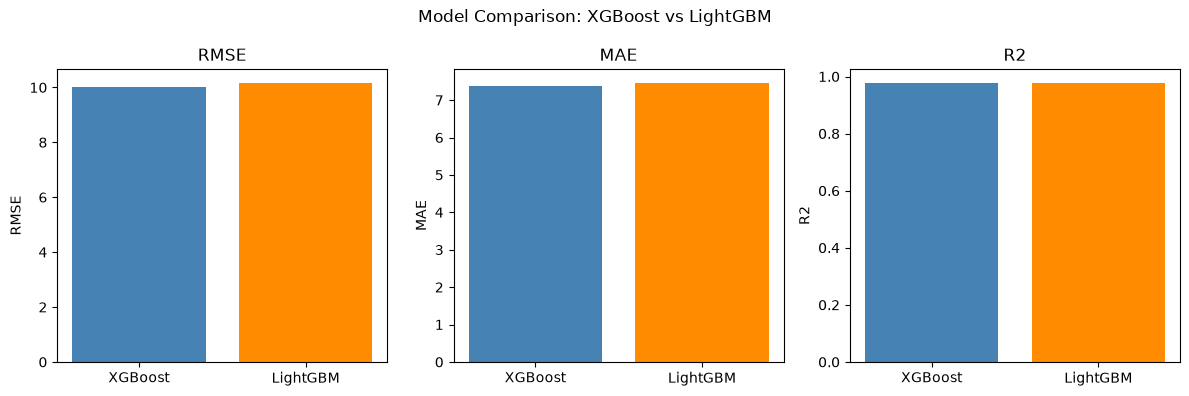

Comparison saved


In [8]:
results = pd.DataFrame({
    "Model": ["XGBoost", "LightGBM"],
    "RMSE": [rmse, rmse_lgb],
    "MAE": [mae, mae_lgb],
    "R2": [r2, r2_lgb]
})
print(results.to_string(index=False))

fig, axes = plt.subplots(1, 3, figsize=(12, 4))
for i, metric in enumerate(["RMSE", "MAE", "R2"]):
    axes[i].bar(results["Model"], results[metric], 
                color=["steelblue", "darkorange"])
    axes[i].set_title(metric)
    axes[i].set_ylabel(metric)
plt.suptitle("Model Comparison: XGBoost vs LightGBM")
plt.tight_layout()
plt.savefig(FIGURES / "model_comparison.png", dpi=150)
plt.show()
print("Comparison saved")

In [9]:
import joblib
from pathlib import Path

MODELS = Path("../src/models")
MODELS.mkdir(parents=True, exist_ok=True)

joblib.dump(xgb_model, MODELS / "xgboost_baseline.pkl")
joblib.dump(lgb_model, MODELS / "lightgbm_baseline.pkl")

np.save(MODELS / "X_test.npy", X_test.values)
np.save(MODELS / "y_test.npy", y_test.values)
pd.DataFrame(X_test).to_parquet(MODELS / "X_test.parquet")

print("Models and test data saved")
print("XGBoost:", MODELS / "xgboost_baseline.pkl")
print("LightGBM:", MODELS / "lightgbm_baseline.pkl")

Models and test data saved
XGBoost: ../src/models/xgboost_baseline.pkl
LightGBM: ../src/models/lightgbm_baseline.pkl


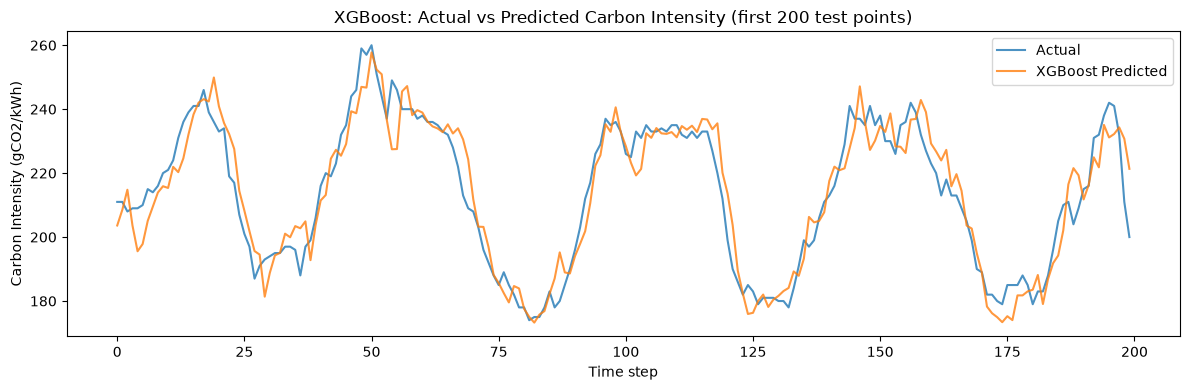

Prediction plot saved


In [10]:
fig, ax = plt.subplots(figsize=(12, 4))
ax.plot(y_test.values[:200], label="Actual", alpha=0.8)
ax.plot(y_pred_xgb[:200], label="XGBoost Predicted", alpha=0.8)
ax.set_title("XGBoost: Actual vs Predicted Carbon Intensity (first 200 test points)")
ax.set_xlabel("Time step")
ax.set_ylabel("Carbon Intensity (gCO2/kWh)")
ax.legend()
plt.tight_layout()
plt.savefig(FIGURES / "xgboost_predictions.png", dpi=150)
plt.show()
print("Prediction plot saved")